# Data Profiling y Calidad de Datos - SIAF Ingresos

## Objetivo
Este notebook documenta el profiling de la fuente SIAF Ingresos en la capa Bronze. El objetivo es describir la estructura del dataset, revisar su cobertura temporal y evaluar su calidad con ocho dimensiones que luego puedan defenderse en clase de forma clara.

## Herramientas
- Python con `pandas`, `numpy` y `matplotlib`
- Archivos CSV aterrizados en `data/bronze/ingresos`
- Diccionario de datos `Ingresos_Diccionario.csv`

## Alcance
Se consolidan todos los archivos anuales disponibles de ingresos, desde 2012 hasta 2026. Para que el notebook sea manejable, se leen todas las filas pero solo las columnas clave para el profiling y la evaluacion de calidad.


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
INGRESOS_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'ingresos'

KEY_COLUMNS = [
    'ANO_DOC', 'MES_DOC', 'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE',
    'DEPARTAMENTO_EJECUTORA', 'DEPARTAMENTO_EJECUTORA_NOMBRE', 'PROVINCIA_EJECUTORA',
    'PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA', 'DISTRITO_EJECUTORA_NOMBRE',
    'SEC_EJEC', 'PLIEGO', 'EJECUTORA', 'FUENTE_FINANCIAMIENTO', 'RUBRO',
    'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'TIPO_RECURSO',
    'RUBRO_NOMBRE', 'FUENTE_FINANCIAMIENTO_NOMBRE', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]


## 1. Carga del dataset

En esta primera etapa se identifican todos los CSV de la fuente de ingresos, se leen todas las filas disponibles y se consolidan en un solo dataframe. Tambien se conserva `source_file` para no perder trazabilidad sobre el archivo de origen de cada registro.


In [2]:
data_files = sorted([path for path in INGRESOS_PATH.glob('*.csv') if path.name != 'Ingresos_Diccionario.csv'])
dictionary_file = INGRESOS_PATH / 'Ingresos_Diccionario.csv'

def read_ingresos_file(file_path: Path, key_columns: list[str]) -> pd.DataFrame:
    header = pd.read_csv(file_path, nrows=0, encoding='utf-8-sig', engine='python', on_bad_lines='skip')
    normalized_columns = [column.replace('﻿', '').strip() for column in header.columns]
    normalized_map = dict(zip(header.columns, normalized_columns))
    usecols = [original for original, normalized in normalized_map.items() if normalized in key_columns]

    frame = pd.read_csv(file_path, usecols=usecols, encoding='utf-8-sig', engine='python', on_bad_lines='skip')
    frame.columns = [column.replace('﻿', '').strip() for column in frame.columns]
    frame['source_file'] = file_path.name
    return frame

ingresos_frames = [read_ingresos_file(file_path, KEY_COLUMNS) for file_path in data_files]
ingresos_df = pd.concat(ingresos_frames, ignore_index=True)

for column in ['ANO_DOC', 'MES_DOC', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']:
    ingresos_df[column] = pd.to_numeric(ingresos_df[column], errors='coerce')

for column in ['SEC_EJEC', 'PLIEGO', 'EJECUTORA', 'FUENTE_FINANCIAMIENTO', 'RUBRO', 'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'TIPO_RECURSO']:
    ingresos_df[column] = ingresos_df[column].astype('string')

dictionary_df = pd.read_csv(dictionary_file, encoding='utf-8-sig', low_memory=False) if dictionary_file.exists() else pd.DataFrame()

file_inventory = pd.DataFrame({
    'file_name': [path.name for path in data_files],
    'records_loaded': [len(frame) for frame in ingresos_frames]
})

print(f'Archivos de datos leidos: {len(data_files)}')
print(f'Diccionario disponible: {dictionary_file.exists()}')
print(f'Registros consolidados: {len(ingresos_df):,}'.replace(',', '.'))
display(file_inventory)


Archivos de datos leidos: 15
Diccionario disponible: True
Registros consolidados: 125.294


,file_name,records_loaded
0,2012-Ingreso.csv,7906
1,2013-Ingreso.csv,15111
2,2014-Ingreso.csv,7791
3,2015-Ingreso.csv,7475
4,2016-Ingreso.csv,7475
5,2017-Ingreso.csv,7421
6,2018-Ingreso.csv,7425
7,2019-Ingreso.csv,7385
8,2020-Ingreso.csv,7365
9,2021-Ingreso.csv,7349


## 2. Entendimiento inicial de la estructura

Antes de perfilar y evaluar calidad, conviene responder tres preguntas basicas: cuantas filas hay, que columnas se estan usando y como se ven los primeros registros. Esta seccion sirve para que el lector entienda rapidamente el contenido del dataset antes de entrar a las metricas.


In [3]:
column_summary = pd.DataFrame({
    'column': ingresos_df.columns,
    'dtype': ingresos_df.dtypes.astype(str).values,
    'non_null_count': ingresos_df.notna().sum().values,
    'missing_ratio': ingresos_df.isna().mean().round(4).values,
    'unique_values': [ingresos_df[column].nunique(dropna=True) for column in ingresos_df.columns],
}).sort_values(['missing_ratio', 'unique_values'], ascending=[False, False])

print(f'Dimension del dataset consolidado: {ingresos_df.shape[0]:,} filas x {ingresos_df.shape[1]:,} columnas'.replace(',', '.'))
display(ingresos_df.head())
display(column_summary)
display(ingresos_df.describe(include='all').T)

if not dictionary_df.empty:
    display(dictionary_df.head(10))


Dimension del dataset consolidado: 125.294 filas x 26 columnas


,ANO_DOC,MES_DOC,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,PLIEGO,SEC_EJEC,EJECUTORA,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,FUENTE_FINANCIAMIENTO,FUENTE_FINANCIAMIENTO_NOMBRE,RUBRO,RUBRO_NOMBRE,TIPO_RECURSO,GENERICA,SUBGENERICA,ESPECIFICA,ESPECIFICA_DET,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,source_file
0,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,3.0,44789.0,44789.0,577.00,2012-Ingreso.csv
1,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,4.0,0.0,0.0,0.00,2012-Ingreso.csv
2,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,2.0,17500.0,17500.0,1230.00,2012-Ingreso.csv
3,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,2.0,1.0,1.0,0.0,0.0,0.00,2012-Ingreso.csv
4,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,2.0,1.0,99.0,31706.0,31706.0,5515.96,2012-Ingreso.csv


,column,dtype,non_null_count,missing_ratio,unique_values
24,MONTO_RECAUDADO,float64,125291,0.0,53206
23,MONTO_PIM,float64,125291,0.0,9610
22,MONTO_PIA,float64,125289,0.0,3344
5,SEC_EJEC,string,125293,0.0,156
12,DISTRITO_EJECUTORA_NOMBRE,object,125290,0.0,74
10,PROVINCIA_EJECUTORA_NOMBRE,object,125292,0.0,57
17,TIPO_RECURSO,string,125290,0.0,46
6,EJECUTORA,string,125292,0.0,43
9,PROVINCIA_EJECUTORA,object,125292,0.0,36
11,DISTRITO_EJECUTORA,object,125290,0.0,22


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ANO_DOC,125293.0,NaN,NaN,NaN,2018.804969,4.496486,2012.0,2015.0,2019.0,2023.0,2026.0
MES_DOC,125293.0,NaN,NaN,NaN,5.915638,3.714621,1.0,2.0,6.0,9.0,12.0
NIVEL_GOBIERNO,125291,1,R,125291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NIVEL_GOBIERNO_NOMBRE,125294,1,GOBIERNOS REGIONALES,125294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLIEGO,125290,9,441.0,66014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEC_EJEC,125293,156,742.0,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EJECUTORA,125292,43,1.0,14047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEPARTAMENTO_EJECUTORA,125292.0,13.0,2.0,61781.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEPARTAMENTO_EJECUTORA_NOMBRE,125291,9,ANCASH,66014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROVINCIA_EJECUTORA,125292.0,36.0,1.0,52792.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,VARIABLE,TIPO_DATO,DESCRIPCION
0,ANO_DOC,Numérico,Año del documento en que se realizaron los rec...
1,MES_DOC,Numérico,Mes del documento en que se realizaron los rec...
2,NIVEL_GOBIERNO,Carácter,Carácter que identifica el Nivel de Gobierno: ...
3,NIVEL_GOBIERNO_NOMBRE,Carácter,"Descripción de Nivel de Gobierno: Nacional, Re..."
4,SECTOR,Carácter,Código de Sector al que pertenece la Entidad.
5,SECTOR_NOMBRE,Carácter,Descripción de código del Sector al que perten...
6,PLIEGO,Carácter,Código de Pliego al que pertenece la Entidad.
7,PLIEGO_NOMBRE,Carácter,Descripción de código del Pliego al que perten...
8,SEC_EJEC,Carácter,Código que identifica a una Entidad.
9,EJECUTORA,Carácter,Código de la cadena institucional que identifi...


## 3. Data Profiling

A partir de aqui comienza formalmente el data profiling. La idea es describir patrones visibles del dataset: nulos, duplicados, cardinalidad, cobertura temporal y comportamiento de montos. Este bloque responde la pregunta: **que contiene realmente la fuente?**


### 3.1 Completitud: valores nulos

Esta subseccion muestra en que columnas faltan datos. No es todavia una nota final de calidad; primero se observa la distribucion de nulos y luego se interpreta en el bloque de las ocho dimensiones.


,column,missing_ratio
0,SUBGENERICA,0.000040
1,MONTO_PIA,0.000040
2,FUENTE_FINANCIAMIENTO,0.000032
3,DISTRITO_EJECUTORA,0.000032
4,TIPO_RECURSO,0.000032
5,DISTRITO_EJECUTORA_NOMBRE,0.000032
6,ESPECIFICA,0.000032
7,PLIEGO,0.000032
8,DEPARTAMENTO_EJECUTORA_NOMBRE,0.000024
9,ESPECIFICA_DET,0.000024


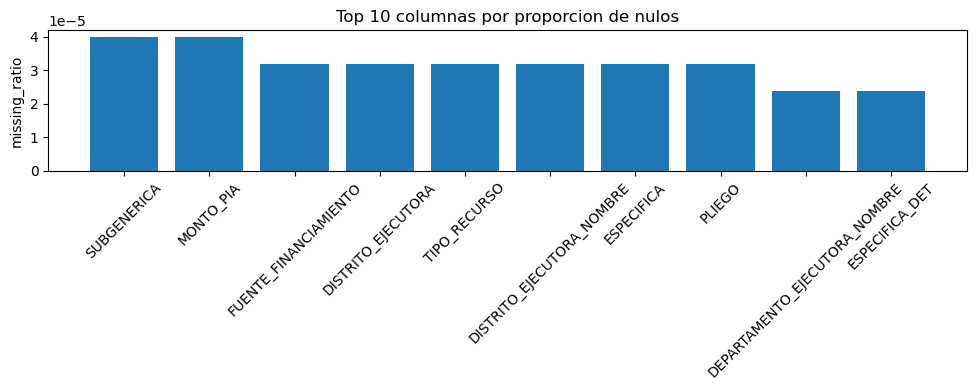

In [4]:
missing_by_column = ingresos_df.isna().mean().sort_values(ascending=False).reset_index()
missing_by_column.columns = ['column', 'missing_ratio']
display(missing_by_column)

top_missing = missing_by_column.head(10)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_missing['column'], top_missing['missing_ratio'], color='tab:blue')
ax.set_title('Top 10 columnas por proporcion de nulos')
ax.set_ylabel('missing_ratio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Duplicados

Aqui se revisan dos cosas: duplicados exactos y duplicados usando una clave candidata de negocio. Esto ayuda a saber si el consolidado podria estar contando registros repetidos.


In [5]:
candidate_key = ['ANO_DOC', 'MES_DOC', 'SEC_EJEC', 'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'FUENTE_FINANCIAMIENTO', 'RUBRO', 'TIPO_RECURSO']
exact_duplicate_ratio = ingresos_df.duplicated().mean()
candidate_duplicate_ratio = ingresos_df.duplicated(subset=candidate_key).mean()

duplicate_summary = pd.DataFrame([
    {'revision': 'Duplicados exactos', 'ratio': round(exact_duplicate_ratio, 4), 'records': int(ingresos_df.duplicated().sum())},
    {'revision': 'Duplicados por clave candidata', 'ratio': round(candidate_duplicate_ratio, 4), 'records': int(ingresos_df.duplicated(subset=candidate_key).sum())},
])
display(duplicate_summary)


,revision,ratio,records
0,Duplicados exactos,0.0003,42
1,Duplicados por clave candidata,0.0252,3161


### 3.3 Cardinalidad y distribucion de categorias

Esta parte resume que tan variadas son las categorias principales del dataset. Sirve para identificar niveles de gobierno, rubros y fuentes de financiamiento mas frecuentes.


In [6]:
cardinality_df = pd.DataFrame({
    'column': ingresos_df.columns,
    'unique_values': [ingresos_df[column].nunique(dropna=True) for column in ingresos_df.columns]
}).sort_values('unique_values', ascending=False)

level_counts = ingresos_df['NIVEL_GOBIERNO_NOMBRE'].value_counts(dropna=False).reset_index()
level_counts.columns = ['nivel_gobierno', 'records']

rubro_counts = ingresos_df['RUBRO_NOMBRE'].value_counts(dropna=False).head(10).reset_index()
rubro_counts.columns = ['rubro', 'records']

fuente_counts = ingresos_df['FUENTE_FINANCIAMIENTO_NOMBRE'].value_counts(dropna=False).head(10).reset_index()
fuente_counts.columns = ['fuente_financiamiento', 'records']

display(cardinality_df.head(15))
display(level_counts)
display(rubro_counts)
display(fuente_counts)


,column,unique_values
24,MONTO_RECAUDADO,53206
23,MONTO_PIM,9610
22,MONTO_PIA,3344
5,SEC_EJEC,156
12,DISTRITO_EJECUTORA_NOMBRE,74
10,PROVINCIA_EJECUTORA_NOMBRE,57
17,TIPO_RECURSO,46
6,EJECUTORA,43
9,PROVINCIA_EJECUTORA,36
11,DISTRITO_EJECUTORA,22


,nivel_gobierno,records
0,GOBIERNOS REGIONALES,125294


,rubro,records
0,RECURSOS DIRECTAMENTE RECAUDADOS,92680
1,"CANON Y SOBRECANON, REGALIAS, RENTA DE ADUANAS...",17222
2,DONACIONES Y TRANSFERENCIAS,10002
3,FONDO DE COMPENSACION REGIONAL - FONCOR,2913
4,RECURSOS POR OPERACIONES OFICIALES DE CREDITO,2467
5,CONTRIBUCIONES A FONDOS,6
6,None,2
7,REC,1
8,NaN,1


,fuente_financiamiento,records
0,RECURSOS DIRECTAMENTE RECAUDADOS,92679
1,RECURSOS DETERMINADOS,20143
2,DONACIONES Y TRANSFERENCIAS,10002
3,RECURSOS POR OPERACIONES OFICIALES DE CREDITO,2467
4,None,2
5,RECURSOS D,1


### 3.4 Perfil temporal

Aqui se observa como se distribuyen los registros por ano. Como la fuente consolida muchos archivos anuales, esta visualizacion deja claro si realmente se estan leyendo todos los anos esperados.


,ANO_DOC,records
0,2012.0,7906
1,2013.0,15111
2,2014.0,7791
3,2015.0,7475
4,2016.0,7475
5,2017.0,7421
6,2018.0,7425
7,2019.0,7385
8,2020.0,7365
9,2021.0,7349


,ANO_DOC,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO
0,2012.0,1.942560e+08,1.106156e+09,1.133458e+09
1,2013.0,5.934826e+08,1.375646e+09,1.150899e+09
2,2014.0,2.368656e+08,4.059881e+08,4.067285e+08
3,2015.0,1.267464e+08,4.009354e+08,4.080740e+08
4,2016.0,1.329643e+08,4.669687e+08,4.698548e+08
5,2017.0,2.224315e+08,6.701201e+08,5.525393e+08
6,2018.0,3.483248e+08,1.273884e+09,1.129449e+09
7,2019.0,3.566529e+08,9.580720e+08,9.811368e+08
8,2020.0,3.868174e+08,1.014166e+09,9.676597e+08
9,2021.0,4.947137e+08,1.123456e+09,1.222820e+09


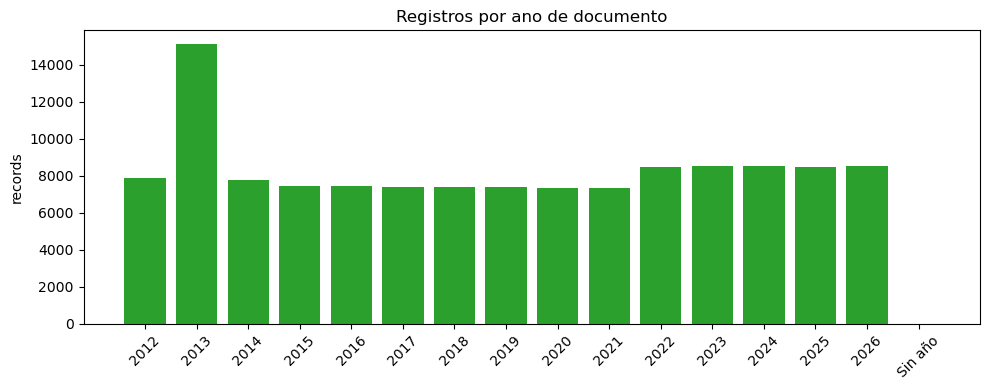

In [7]:
records_by_year = ingresos_df['ANO_DOC'].value_counts(dropna=False).sort_index().reset_index()
records_by_year.columns = ['ANO_DOC', 'records']

amounts_by_year = ingresos_df.groupby('ANO_DOC')[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].sum(min_count=1).reset_index()

display(records_by_year)
display(amounts_by_year)

fig, ax = plt.subplots(figsize=(10, 4))
year_labels = records_by_year['ANO_DOC'].apply(lambda value: 'Sin año' if pd.isna(value) else str(int(value)))
ax.bar(year_labels, records_by_year['records'], color='tab:green')
ax.set_title('Registros por ano de documento')
ax.set_ylabel('records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.5 Perfil de montos

En la fuente de ingresos, los montos son una variable central. Por eso se revisan estadisticos descriptivos y una visualizacion simple para detectar dispersion o posibles valores atipicos.


,count,mean,std,min,25%,50%,75%,max
MONTO_PIA,125289.0,79408.818428,3.028771e+06,0.0,0.00,0.00,0.00,3.323926e+08
MONTO_PIM,125291.0,147898.151775,3.479762e+06,-80856737.0,0.00,0.00,0.00,3.323926e+08
MONTO_RECAUDADO,125291.0,135971.542155,3.036782e+06,-125075088.0,0.44,356.53,3270.05,2.782963e+08


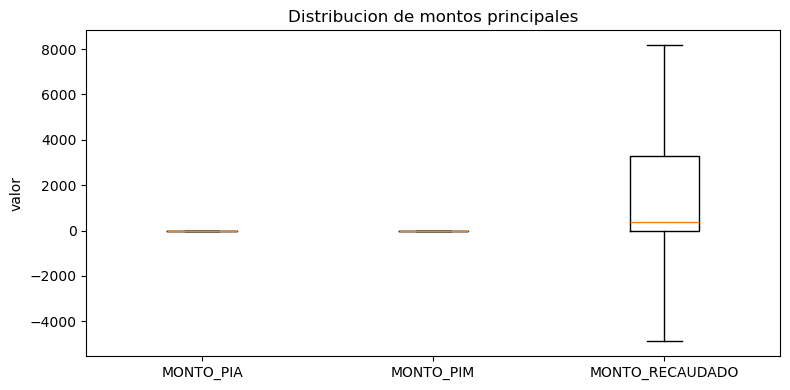

In [8]:
amount_columns = ['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']
display(ingresos_df[amount_columns].describe().T)

plot_data = [ingresos_df[column].dropna() for column in amount_columns]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(plot_data, labels=amount_columns, showfliers=False)
ax.set_title('Distribucion de montos principales')
ax.set_ylabel('valor')
plt.tight_layout()
plt.show()


## 4. Evaluacion de las 8 dimensiones de calidad

**A partir de esta seccion comienza formalmente la evaluacion de calidad de datos para la fuente de ingresos.** Cada dimension se explica de forma separada para que puedas defenderla oralmente: que significa, como se midio y que resultado obtuvo.


In [9]:
def classify_score(score: float) -> str:
    if pd.isna(score):
        return 'No evaluado'
    if score >= 0.95:
        return 'Alto'
    if score >= 0.80:
        return 'Medio'
    return 'Bajo'

core_columns = ['ANO_DOC', 'MES_DOC', 'SEC_EJEC', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']
missing_core_ratio = ingresos_df[core_columns].isna().mean().mean()

duplicate_ratio = ingresos_df.duplicated(subset=candidate_key).mean()

valid_month_ratio = ingresos_df['MES_DOC'].between(1, 12).mean()
valid_year_ratio = ingresos_df['ANO_DOC'].between(2012, 2026).mean()
valid_level_ratio = ingresos_df['NIVEL_GOBIERNO'].isin(['N', 'R', 'L']).mean()
validez_ratio = np.nanmean([valid_month_ratio, valid_year_ratio, valid_level_ratio])

dept_consistency_ratio = ((ingresos_df['DEPARTAMENTO_EJECUTORA'].notna()) == (ingresos_df['DEPARTAMENTO_EJECUTORA_NOMBRE'].notna())).mean()
prov_consistency_ratio = ((ingresos_df['PROVINCIA_EJECUTORA'].notna()) == (ingresos_df['PROVINCIA_EJECUTORA_NOMBRE'].notna())).mean()
dist_consistency_ratio = ((ingresos_df['DISTRITO_EJECUTORA'].notna()) == (ingresos_df['DISTRITO_EJECUTORA_NOMBRE'].notna())).mean()
consistency_ratio = np.nanmean([dept_consistency_ratio, prov_consistency_ratio, dist_consistency_ratio])

non_negative_ratio = ((ingresos_df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']] >= 0) | ingresos_df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].isna()).all(axis=1).mean()

integrity_ratio = ingresos_df[['SEC_EJEC', 'PLIEGO', 'EJECUTORA']].notna().all(axis=1).mean()

expected_years = set(range(2012, 2027))
observed_years = set(ingresos_df['ANO_DOC'].dropna().astype(int).unique())
actualidad_ratio = len(observed_years & expected_years) / len(expected_years)

traceability_ratio = ingresos_df['source_file'].notna().mean()

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporcion de duplicados por clave candidata', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'promedio de reglas de ano, mes y nivel', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'coherencia entre codigos y nombres geograficos', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'proporcion de montos no negativos', 'score': round(non_negative_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de SEC_EJEC, PLIEGO y EJECUTORA', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'cobertura de anos esperados 2012-2026', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Trazabilidad', 'metric': 'presencia de source_file', 'score': round(traceability_ratio, 4)},
])
quality_summary['nivel'] = quality_summary['score'].apply(classify_score)
quality_summary


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0000,Alto
1,Unicidad,1 - proporcion de duplicados por clave candidata,0.9748,Alto
2,Validez,"promedio de reglas de ano, mes y nivel",1.0000,Alto
3,Consistencia,coherencia entre codigos y nombres geograficos,1.0000,Alto
4,Exactitud,proporcion de montos no negativos,0.9875,Alto
5,Integridad,"presencia conjunta de SEC_EJEC, PLIEGO y EJECU...",1.0000,Alto
6,Actualidad,cobertura de anos esperados 2012-2026,1.0000,Alto
7,Trazabilidad,presencia de source_file,1.0000,Alto


### 4.1 Completitud

**Que significa:** revisar si los campos minimos para analizar la fuente estan presentes.

**Como se midio:** se calculo el promedio de nulos en columnas clave como ano, mes, ejecutora y montos. Mientras mas cercano a 1 este el score, menor es la proporcion de vacios.


In [10]:
completitud_detail = pd.DataFrame({
    'column': core_columns,
    'missing_ratio': ingresos_df[core_columns].isna().mean().round(4).values,
    'completeness_score': (1 - ingresos_df[core_columns].isna().mean()).round(4).values,
})
display(quality_summary[quality_summary['dimension'] == 'Completitud'])
display(completitud_detail)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0,Alto


,column,missing_ratio,completeness_score
0,ANO_DOC,0.0,1.0
1,MES_DOC,0.0,1.0
2,SEC_EJEC,0.0,1.0
3,MONTO_PIA,0.0,1.0
4,MONTO_PIM,0.0,1.0
5,MONTO_RECAUDADO,0.0,1.0


### 4.2 Unicidad

**Que significa:** verificar si una misma combinacion de negocio aparece repetida demasiadas veces.

**Como se midio:** se uso una clave candidata formada por ano, mes, ejecutora y clasificaciones presupuestales. Un score alto implica baja proporcion de duplicados.


In [11]:
unicidad_detail = pd.DataFrame([
    {'revision': 'Duplicados exactos', 'ratio': round(exact_duplicate_ratio, 4), 'records': int(ingresos_df.duplicated().sum())},
    {'revision': 'Duplicados por clave candidata', 'ratio': round(duplicate_ratio, 4), 'records': int(ingresos_df.duplicated(subset=candidate_key).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Unicidad'])
display(unicidad_detail)


,dimension,metric,score,nivel
1,Unicidad,1 - proporcion de duplicados por clave candidata,0.9748,Alto


,revision,ratio,records
0,Duplicados exactos,0.0003,42
1,Duplicados por clave candidata,0.0252,3161


### 4.3 Validez

**Que significa:** comprobar si los valores respetan reglas basicas del dominio.

**Como se midio:** se reviso si el mes esta entre 1 y 12, si el ano cae en el rango 2012-2026 y si el nivel de gobierno pertenece a los codigos esperados.


In [12]:
validez_detail = pd.DataFrame([
    {'regla': 'ANO_DOC entre 2012 y 2026', 'score': round(valid_year_ratio, 4)},
    {'regla': 'MES_DOC entre 1 y 12', 'score': round(valid_month_ratio, 4)},
    {'regla': 'NIVEL_GOBIERNO en N, R o L', 'score': round(valid_level_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Validez'])
display(validez_detail)


,dimension,metric,score,nivel
2,Validez,"promedio de reglas de ano, mes y nivel",1.0,Alto


,regla,score
0,ANO_DOC entre 2012 y 2026,1.0
1,MES_DOC entre 1 y 12,1.0
2,"NIVEL_GOBIERNO en N, R o L",1.0


### 4.4 Consistencia

**Que significa:** revisar si los atributos relacionados se comportan de forma coherente.

**Como se midio:** se comparo la presencia simultanea de codigos y nombres de departamento, provincia y distrito. Si aparece el codigo pero no el nombre, o al reves, la consistencia baja.


In [13]:
consistencia_detail = pd.DataFrame([
    {'regla': 'Departamento codigo y nombre', 'score': round(dept_consistency_ratio, 4)},
    {'regla': 'Provincia codigo y nombre', 'score': round(prov_consistency_ratio, 4)},
    {'regla': 'Distrito codigo y nombre', 'score': round(dist_consistency_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Consistencia'])
display(consistencia_detail)


,dimension,metric,score,nivel
3,Consistencia,coherencia entre codigos y nombres geograficos,1.0,Alto


,regla,score
0,Departamento codigo y nombre,1.0
1,Provincia codigo y nombre,1.0
2,Distrito codigo y nombre,1.0


### 4.5 Exactitud

**Que significa:** en este caso, revisar si los montos tienen un comportamiento razonable para el uso analitico.

**Como se midio:** se verifico la proporcion de registros donde `MONTO_PIA`, `MONTO_PIM` y `MONTO_RECAUDADO` son no negativos o estan vacios.


In [14]:
negative_rows = int((ingresos_df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']] < 0).any(axis=1).sum())
exactitud_detail = pd.DataFrame([
    {'regla': 'Montos no negativos', 'score': round(non_negative_ratio, 4), 'rows_with_negative_values': negative_rows},
])
display(quality_summary[quality_summary['dimension'] == 'Exactitud'])
display(exactitud_detail)


,dimension,metric,score,nivel
4,Exactitud,proporcion de montos no negativos,0.9875,Alto


,regla,score,rows_with_negative_values
0,Montos no negativos,0.9875,1571


### 4.6 Integridad

**Que significa:** evaluar si los campos que identifican la unidad ejecutora llegan completos dentro del mismo registro.

**Como se midio:** se reviso la presencia conjunta de `SEC_EJEC`, `PLIEGO` y `EJECUTORA`.


In [15]:
integridad_detail = pd.DataFrame([
    {'regla': 'SEC_EJEC, PLIEGO y EJECUTORA presentes', 'score': round(integrity_ratio, 4), 'complete_rows': int(ingresos_df[['SEC_EJEC', 'PLIEGO', 'EJECUTORA']].notna().all(axis=1).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Integridad'])
display(integridad_detail)


,dimension,metric,score,nivel
5,Integridad,"presencia conjunta de SEC_EJEC, PLIEGO y EJECU...",1.0,Alto


,regla,score,complete_rows
0,"SEC_EJEC, PLIEGO y EJECUTORA presentes",1.0,125289


### 4.7 Actualidad

**Que significa:** revisar si la fuente cubre el horizonte temporal que se esperaba para el parcial.

**Como se midio:** se compararon los anos observados en el consolidado contra el rango esperado 2012-2026.


In [16]:
actualidad_detail = pd.DataFrame({
    'observed_year': sorted(observed_years),
})
display(quality_summary[quality_summary['dimension'] == 'Actualidad'])
display(actualidad_detail)


,dimension,metric,score,nivel
6,Actualidad,cobertura de anos esperados 2012-2026,1.0,Alto


,observed_year
0,2012
1,2013
2,2014
3,2015
4,2016
5,2017
6,2018
7,2019
8,2020
9,2021


### 4.8 Trazabilidad

**Que significa:** asegurar que cada registro pueda asociarse a su archivo de origen.

**Como se midio:** se verifico la presencia de `source_file` en los registros consolidados.


In [17]:
trazabilidad_detail = ingresos_df['source_file'].value_counts(dropna=False).reset_index()
trazabilidad_detail.columns = ['source_file', 'records']
display(quality_summary[quality_summary['dimension'] == 'Trazabilidad'])
display(trazabilidad_detail)


,dimension,metric,score,nivel
7,Trazabilidad,presencia de source_file,1.0,Alto


,source_file,records
0,2013-Ingreso.csv,15111
1,2026-Ingreso_api.csv,8560
2,2023-Ingreso_api.csv,8527
3,2024-Ingreso_api.csv,8507
4,2025-Ingreso_api.csv,8502
5,2022-Ingreso_api.csv,8495
6,2012-Ingreso.csv,7906
7,2014-Ingreso.csv,7791
8,2015-Ingreso.csv,7475
9,2016-Ingreso.csv,7475


## 5. Resumen consolidado

Esta tabla concentra las ocho dimensiones, la metrica utilizada y un nivel interpretativo simple. Es la mejor vista para una explicacion rapida ante el profesor.


In [18]:
display(quality_summary)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0000,Alto
1,Unicidad,1 - proporcion de duplicados por clave candidata,0.9748,Alto
2,Validez,"promedio de reglas de ano, mes y nivel",1.0000,Alto
3,Consistencia,coherencia entre codigos y nombres geograficos,1.0000,Alto
4,Exactitud,proporcion de montos no negativos,0.9875,Alto
5,Integridad,"presencia conjunta de SEC_EJEC, PLIEGO y EJECU...",1.0000,Alto
6,Actualidad,cobertura de anos esperados 2012-2026,1.0000,Alto
7,Trazabilidad,presencia de source_file,1.0000,Alto


## 6. Conclusiones

Las conclusiones sintetizan que aprendimos del profiling y que dimension necesita mas atencion.


In [19]:
worst_dimension = quality_summary.sort_values('score').iloc[0]
best_dimension = quality_summary.sort_values('score', ascending=False).iloc[0]
conclusion_lines = [
    f'- Se consolidaron {len(data_files)} archivos y {len(ingresos_df):,} registros de la fuente de ingresos.'.replace(',', '.'),
    f'- La cobertura temporal observada va de {int(min(observed_years))} a {int(max(observed_years))}.',
    f'- La dimension con mejor resultado fue {best_dimension["dimension"]} con score {best_dimension["score"]:.4f}.',
    f'- La dimension que merece mayor explicacion en la defensa es {worst_dimension["dimension"]} con score {worst_dimension["score"]:.4f}.',
    '- En conjunto, la fuente es util para analisis fiscal, pero conviene vigilar los posibles duplicados y los montos atipicos.'
]
display(Markdown('\n'.join(conclusion_lines)))


- Se consolidaron 15 archivos y 125.294 registros de la fuente de ingresos.
- La cobertura temporal observada va de 2012 a 2026.
- La dimension con mejor resultado fue Completitud con score 1.0000.
- La dimension que merece mayor explicacion en la defensa es Unicidad con score 0.9748.
- En conjunto, la fuente es util para analisis fiscal, pero conviene vigilar los posibles duplicados y los montos atipicos.

## 7. Recomendaciones

Esta ultima seccion traduce los hallazgos en acciones concretas. Sirve para demostrar que el profiling no solo describe datos, sino que tambien orienta mejoras del pipeline y del uso analitico posterior.


In [20]:
recommendation_lines = [
    '- Mantener la consolidacion anual y documentar claramente la clave candidata usada para buscar duplicados.',
    '- Revisar los registros con montos negativos antes de cualquier agregacion o analisis de tendencia.',
    '- Conservar `source_file` en capas posteriores para no perder trazabilidad.',
    '- Si se construye una capa Silver, normalizar catalogos geograficos y reglas de validacion como parte del proceso ETL.'
]
display(Markdown('\n'.join(recommendation_lines)))


- Mantener la consolidacion anual y documentar claramente la clave candidata usada para buscar duplicados.
- Revisar los registros con montos negativos antes de cualquier agregacion o analisis de tendencia.
- Conservar `source_file` en capas posteriores para no perder trazabilidad.
- Si se construye una capa Silver, normalizar catalogos geograficos y reglas de validacion como parte del proceso ETL.